# Retail Demand Forecasting and Inventory Replenishment Analysis
This project analyzes retail sales and inventory data to identify demand patterns, detect stockout risks, forecast future demand, and generate data-driven replenishment recommendations. The objective is to improve product availability, reduce lost sales, and support proactive inventory planning across multiple stores.

## Project Objectives
• Identify top-selling products driving demand
• Detect stores and SKUs experiencing stockouts
• Analyze demand trends and seasonality
• Forecast short-term demand using historical sales
• Recommend inventory replenishment quantities using safety stock and reorder point models

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## 2. Data Loading

Load Clean Data (Generated from ETL Pipeline)

In [2]:
sales = pd.read_csv("../data/fact_sales_store_sku_daily.csv")
inventory = pd.read_csv("../data/fact_inventory_store_sku_daily.csv")
replenishment = pd.read_csv("../data/replenishment_inputs_store_sku.csv")

sales.head()

,date,store_id,sku_id,units_sold,revenue,promo_flag,holiday_flag,day_of_week
0,2025-07-04,ST001,SKU0001,3,1177.65,0,0,4
1,2025-07-04,ST001,SKU0002,4,1488.52,0,0,4
2,2025-07-04,ST001,SKU0003,8,1764.48,0,0,4
3,2025-07-04,ST001,SKU0004,10,5397.90,0,0,4
4,2025-07-04,ST001,SKU0005,5,1312.15,0,0,4


## 3. Data Overview

In [3]:
sales.info()
inventory.info()
replenishment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 342674 entries, 0 to 342673
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   date          342674 non-null  object 
 1   store_id      342674 non-null  object 
 2   sku_id        342674 non-null  object 
 3   units_sold    342674 non-null  int64  
 4   revenue       342674 non-null  float64
 5   promo_flag    342674 non-null  int64  
 6   holiday_flag  342674 non-null  int64  
 7   day_of_week   342674 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 20.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341820 entries, 0 to 341819
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           341820 non-null  object 
 1   store_id       341820 non-null  object 
 2   sku_id         341820 non-null  object 
 3   on_hand_units  341820 non-null  int64  
 4   st

## 4. Product Demand Analysis

We identify the products that contribute the most to total sales volume.
Understanding top-selling SKUs helps prioritize inventory allocation.

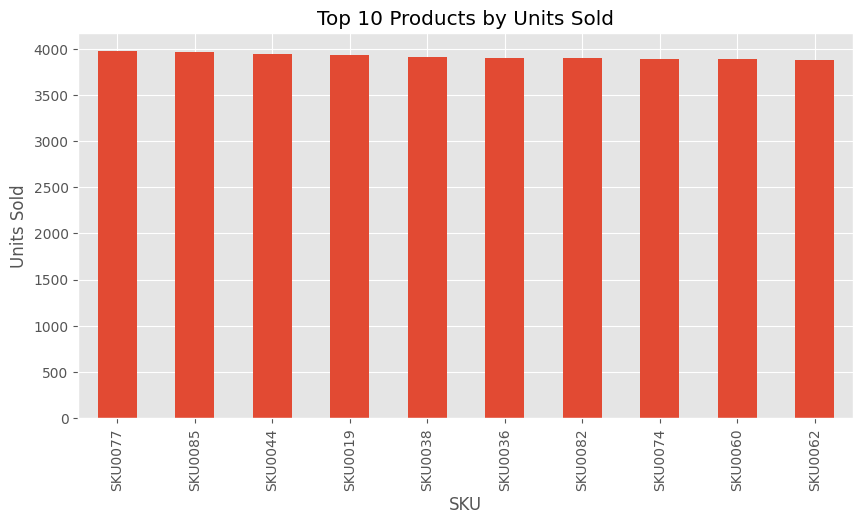

In [4]:
top_products = sales.groupby("sku_id")["units_sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Units Sold")
plt.xlabel("SKU")
plt.ylabel("Units Sold")

plt.show()

##### 5. Store Revenue Performance

This section evaluates revenue contribution across stores to identify high-performing and underperforming locations.

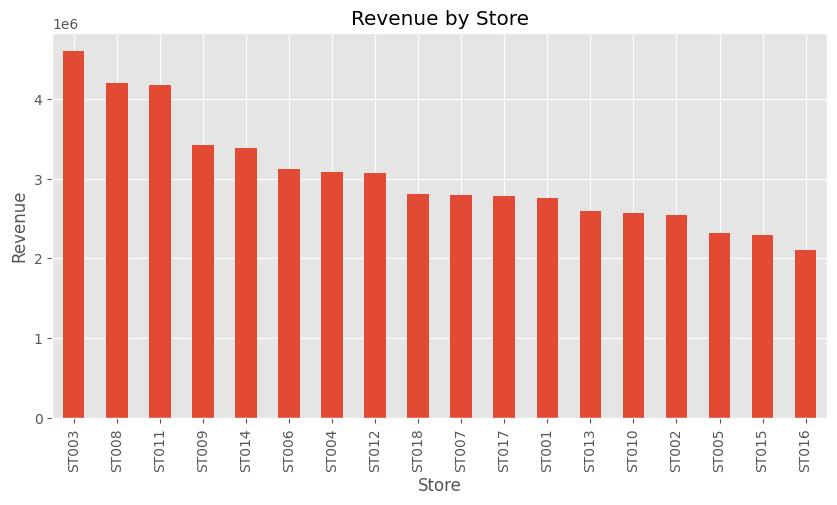

In [5]:
store_revenue = sales.groupby("store_id")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
store_revenue.plot(kind="bar")

plt.title("Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Revenue")

plt.show()

###### 6. Stockout Detection

Total Stockout Events: 341820


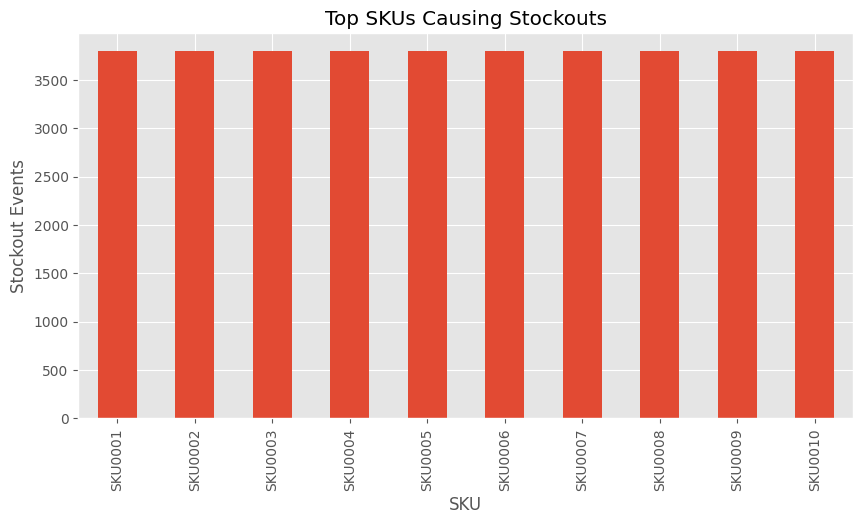

In [6]:
stockouts = inventory[inventory["stockout_flag"] == 1]

print("Total Stockout Events:", len(stockouts))

stockout_skus = stockouts.groupby("sku_id").size().sort_values(ascending=False)

plt.figure(figsize=(10,5))
stockout_skus.head(10).plot(kind="bar")

plt.title("Top SKUs Causing Stockouts")
plt.xlabel("SKU")
plt.ylabel("Stockout Events")

plt.show()

## 7. Inventory Risk Analysis

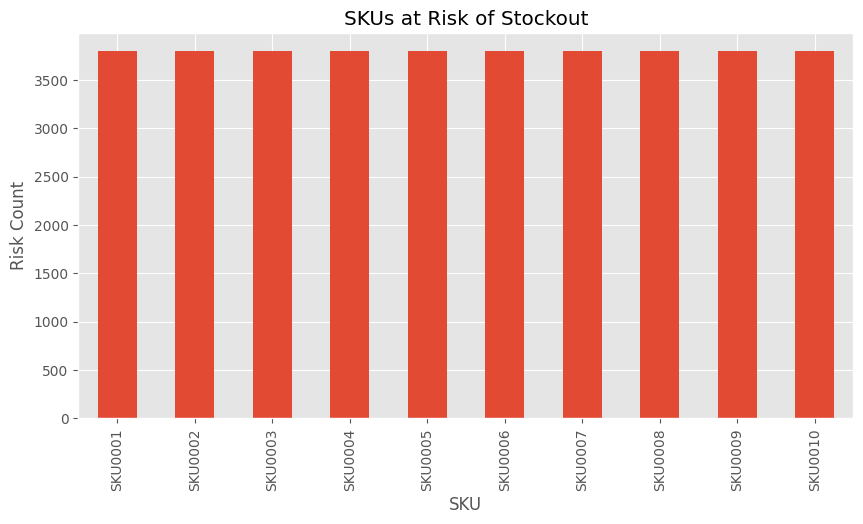

In [7]:
replenishment_candidates = inventory[inventory["days_of_cover"] < 3]

risk_skus = replenishment_candidates.groupby("sku_id").size().sort_values(ascending=False)

plt.figure(figsize=(10,5))
risk_skus.head(10).plot(kind="bar")

plt.title("SKUs at Risk of Stockout")
plt.xlabel("SKU")
plt.ylabel("Risk Count")

plt.show()

### 8. Demand Trend Analysis

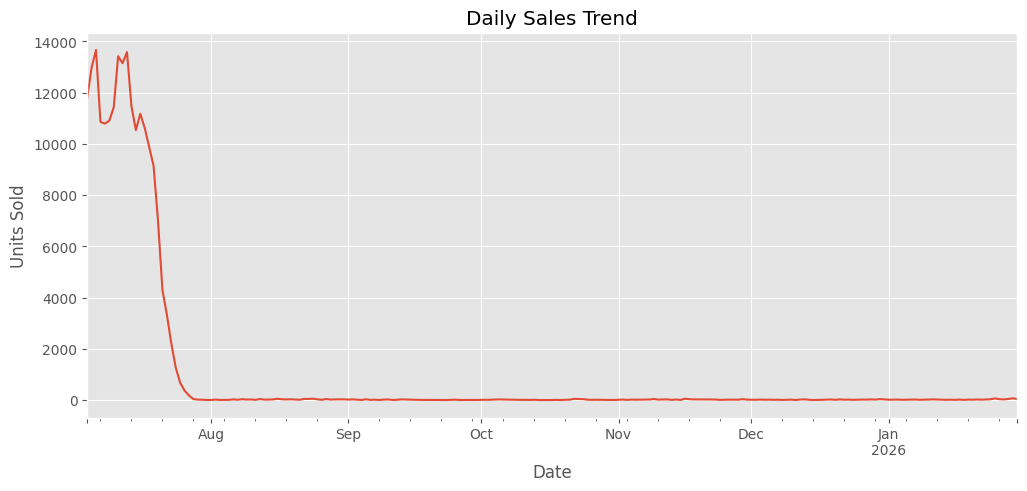

In [8]:
sales["date"] = pd.to_datetime(sales["date"])

daily_sales = sales.groupby("date")["units_sold"].sum()

plt.figure(figsize=(12,5))
daily_sales.plot()

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

## 9. Demand Forecasting (30-Day Projection)

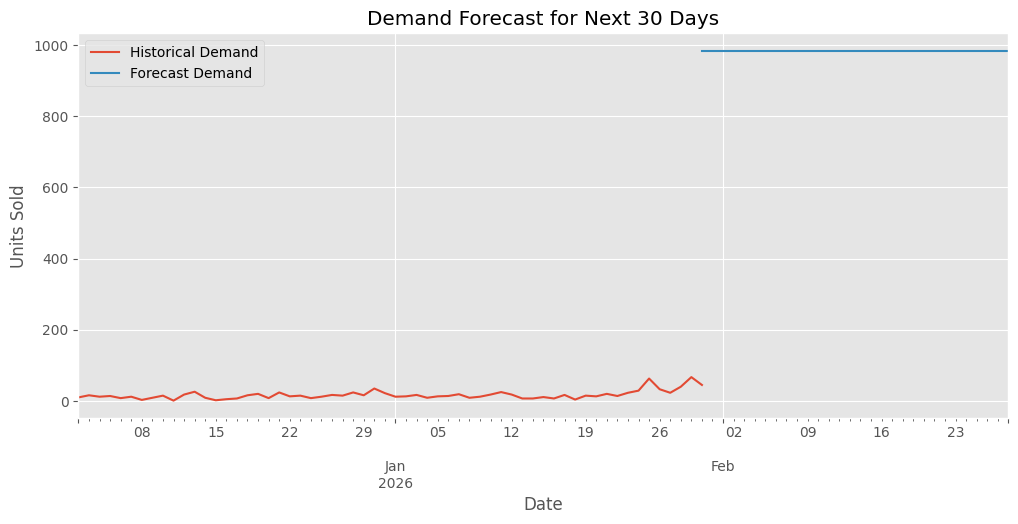

In [9]:
avg_daily_sales = daily_sales.mean()

forecast_days = 30

forecast = pd.Series([avg_daily_sales]*forecast_days)

forecast.index = pd.date_range(
    start=daily_sales.index.max(),
    periods=forecast_days,
    freq="D"
)

plt.figure(figsize=(12,5))

daily_sales.tail(60).plot(label="Historical Demand")
forecast.plot(label="Forecast Demand")

plt.title("Demand Forecast for Next 30 Days")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()

plt.show()

## 10. Inventory Replenishment Model

In [10]:
replenishment.head()

,store_id,sku_id,avg_daily_demand,demand_std_dev,lead_time_days,safety_stock,reorder_point,recommended_order_qty
0,ST001,SKU0001,0.273585,1.039805,7,4.539258,6.454353,3.830189
1,ST001,SKU0002,0.264151,1.073612,7,4.686841,6.535898,3.698113
2,ST001,SKU0003,0.573460,2.447167,7,10.683082,14.697300,8.028436
3,ST001,SKU0004,0.582938,2.076282,7,9.063986,13.144555,8.161137
4,ST001,SKU0005,0.485849,2.122948,7,9.267707,12.668651,6.801887


# 11. Urgent Replenishment Recommendations

In [11]:
urgent_replenishment = replenishment.sort_values(
    by="reorder_point",
    ascending=False
)

urgent_replenishment.head(10)


,store_id,sku_id,avg_daily_demand,demand_std_dev,lead_time_days,safety_stock,reorder_point,recommended_order_qty
687,ST008,SKU0058,1.535545,11.618639,7,50.721050,61.469865,21.497630
193,ST003,SKU0014,1.616114,11.249953,7,49.111556,60.424352,22.625592
804,ST009,SKU0085,1.594340,9.596878,7,41.895071,53.055448,22.320755
871,ST010,SKU0062,1.317536,8.677756,7,37.882655,47.105404,18.445498
1181,ST014,SKU0012,1.339623,8.378359,7,36.575641,45.953000,18.754717
141,ST002,SKU0052,1.037736,8.275957,7,36.128604,43.392755,14.528302
14,ST001,SKU0015,0.981043,8.232318,7,35.938101,42.805400,13.734597
253,ST003,SKU0074,1.597156,7.192840,7,31.400268,42.580363,22.360190
241,ST003,SKU0062,1.516588,7.273138,7,31.750808,42.366922,21.232227
256,ST003,SKU0077,1.630332,6.448760,7,28.151995,39.564317,22.824645


## 12. Key Business Insights

1. Demand is concentrated among a relatively small number of SKUs, suggesting inventory prioritization for these items can significantly improve product availability.
2. Several stores exhibit higher stockout frequencies, indicating potential supply chain or distribution inefficiencies.
3. Historical demand trends show consistent patterns, enabling reliable short-term forecasting.
4. The demand forecast suggests stable product demand over the next 30 days, supporting proactive inventory planning.
5. The replenishment model identifies products approaching reorder thresholds, highlighting opportunities for timely restocking.


## 13. Executive Summary

This analysis integrates sales analytics, inventory monitoring, demand forecasting, and replenishment optimization to improve retail inventory management. By identifying high-demand products, detecting stockout risks, forecasting demand, and recommending replenishment quantities, the project demonstrates how data-driven approaches can support operational decision-making and reduce revenue loss due to inventory shortages